# [LAB-06] 7. Heat Map

## #01. 준비작업

### 1. 패키치 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import pivot_table
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('flights')
origin

📚 어느 항공사의 년/월별 국제선 탑승객 수(출처: seaborn 내장 데이터)


,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121
...,...,...,...
139,1960,August,606
140,1960,September,508
141,1960,October,461
142,1960,November,390


### 3. 데이터 전처리 (1)

- 영문 월 이름을 숫자로 변환

In [3]:
df = origin.copy()
df['month'] = df['month'].map({
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
})

df.head()

,year,month,passengers
0,1949,1,112
1,1949,2,118
2,1949,3,132
3,1949,4,129
4,1949,5,121


### 4. 데이터 전처리 (2)

- 히트맵에 적합한 형태로 데이터 재구조화
  - 히트맵은 피벗 테이블 형태의 테이블을 시각화 한다.

In [4]:
df2 = pivot_table(df, index="year", columns="month", values="passengers")
df2

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1949,112.000,118.000,132.000,129.000,121.000,135.000,148.000,148.000,136.000,119.000,104.000,118.000
1950,115.000,126.000,141.000,135.000,125.000,149.000,170.000,170.000,158.000,133.000,114.000,140.000
1951,145.000,150.000,178.000,163.000,172.000,178.000,199.000,199.000,184.000,162.000,146.000,166.000
1952,171.000,180.000,193.000,181.000,183.000,218.000,230.000,242.000,209.000,191.000,172.000,194.000
1953,196.000,196.000,236.000,235.000,229.000,243.000,264.000,272.000,237.000,211.000,180.000,201.000
1954,204.000,188.000,235.000,227.000,234.000,264.000,302.000,293.000,259.000,229.000,203.000,229.000
1955,242.000,233.000,267.000,269.000,270.000,315.000,364.000,347.000,312.000,274.000,237.000,278.000
1956,284.000,277.000,317.000,313.000,318.000,374.000,413.000,405.000,355.000,306.000,271.000,306.000
1957,315.000,301.000,356.000,348.000,355.000,422.000,465.000,467.000,404.000,347.000,305.000,336.000


### 5. 데이터 전처리 (3)

- 년도 역순으로 정렬

In [5]:
df3 = df2.sort_index(ascending=False)
df3

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1960,417.000,391.000,419.000,461.000,472.000,535.000,622.000,606.000,508.000,461.000,390.000,432.000
1959,360.000,342.000,406.000,396.000,420.000,472.000,548.000,559.000,463.000,407.000,362.000,405.000
1958,340.000,318.000,362.000,348.000,363.000,435.000,491.000,505.000,404.000,359.000,310.000,337.000
1957,315.000,301.000,356.000,348.000,355.000,422.000,465.000,467.000,404.000,347.000,305.000,336.000
1956,284.000,277.000,317.000,313.000,318.000,374.000,413.000,405.000,355.000,306.000,271.000,306.000
1955,242.000,233.000,267.000,269.000,270.000,315.000,364.000,347.000,312.000,274.000,237.000,278.000
1954,204.000,188.000,235.000,227.000,234.000,264.000,302.000,293.000,259.000,229.000,203.000,229.000
1953,196.000,196.000,236.000,235.000,229.000,243.000,264.000,272.000,237.000,211.000,180.000,201.000
1952,171.000,180.000,193.000,181.000,183.000,218.000,230.000,242.000,209.000,191.000,172.000,194.000


## #02. Heatmap 시각화

### 1. 년도/월별 탑승객 수 분포 시각화

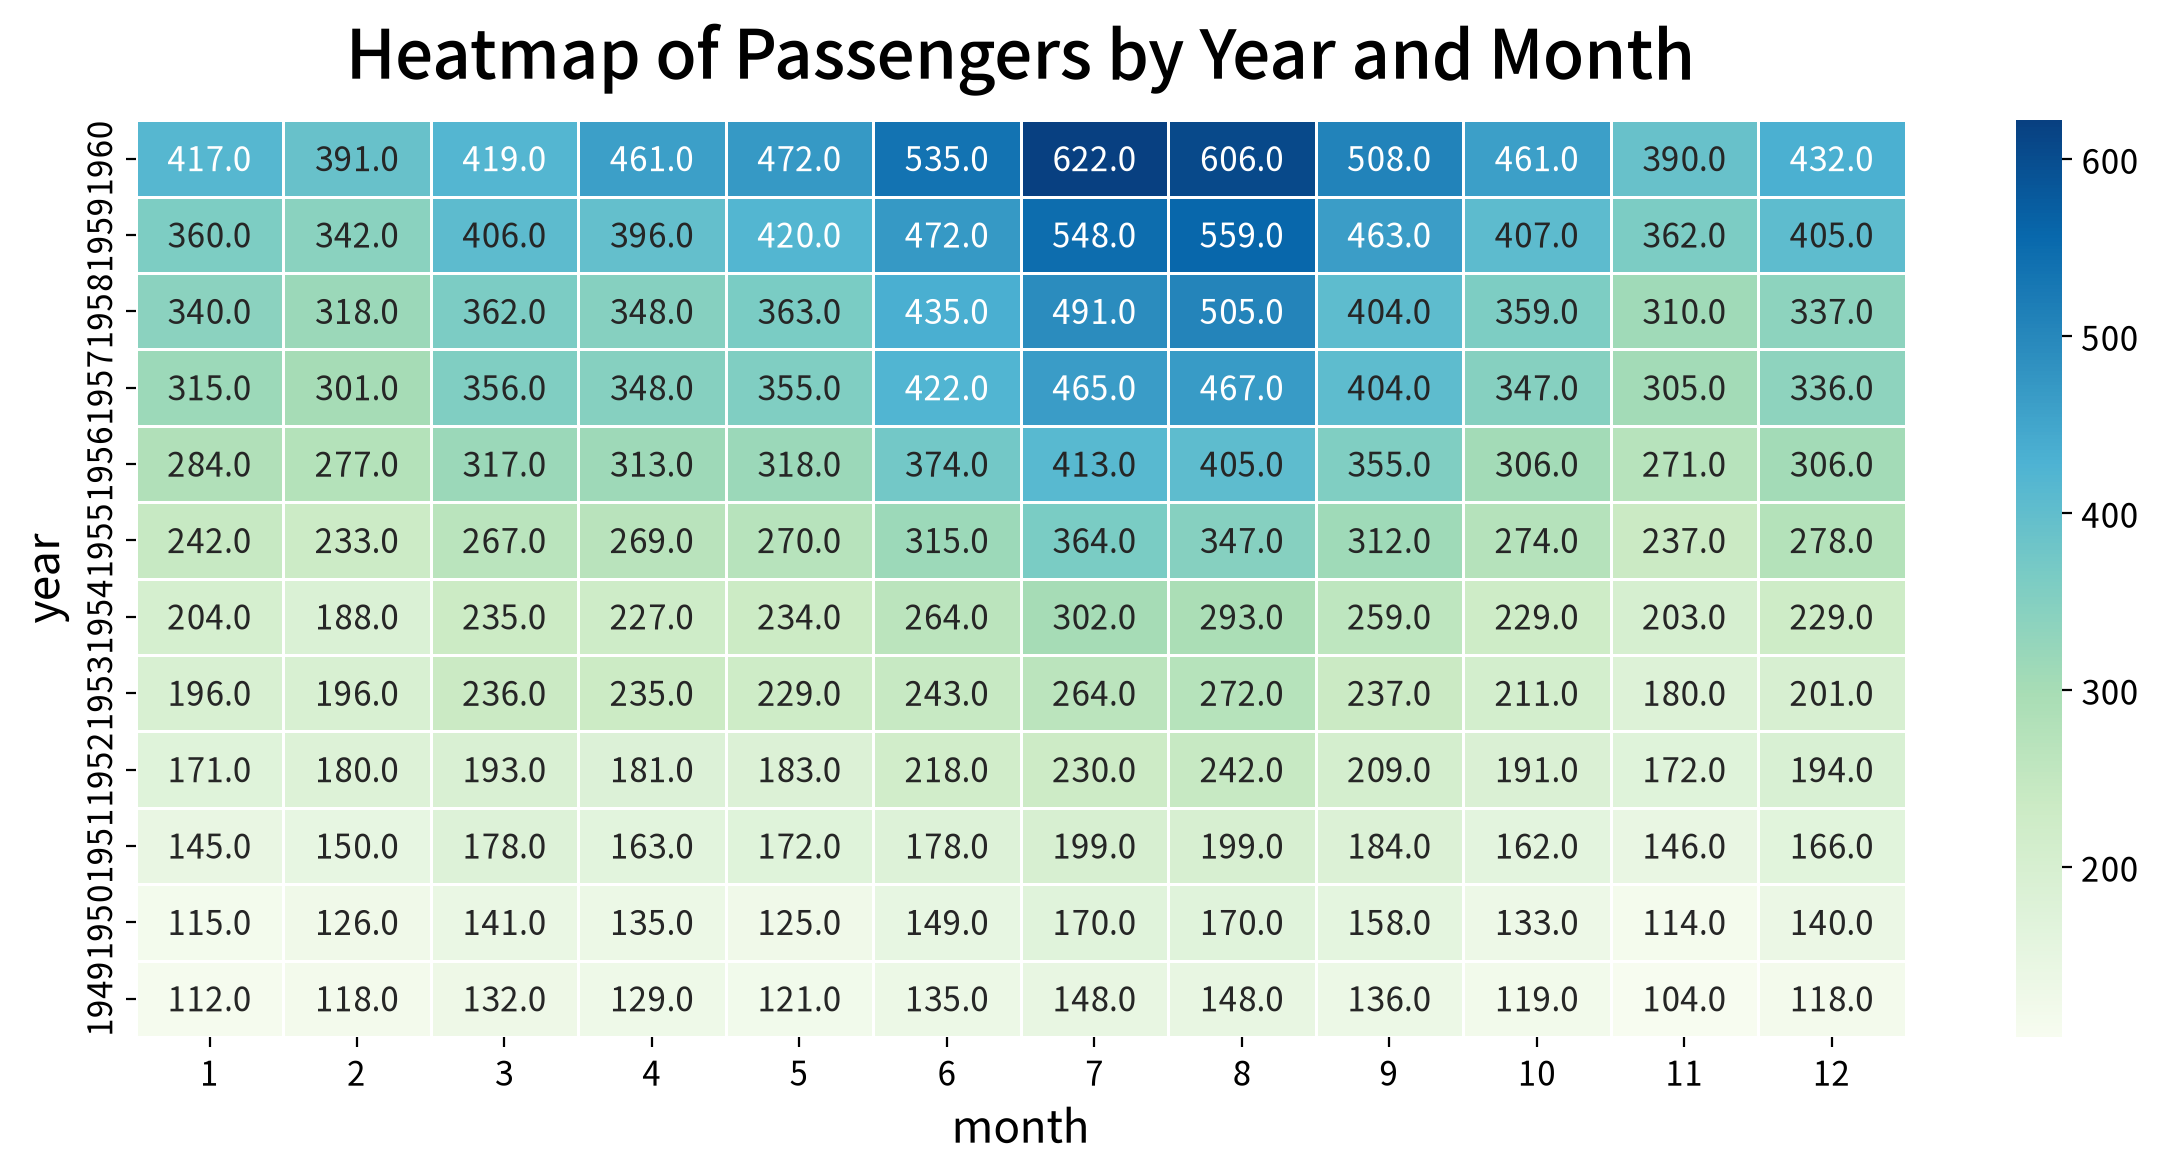

In [6]:
fig, ax = my_plot.init(width=1200, height=600, 
                       title="Heatmap of Passengers by Year and Month",
                       xlabel="Month", ylabel="Year")

ax.grid(False)  # 격자 제거

# 2) heatmap 그리기
# -> annot=True : 수치값을 함께 표시함
# -> fmt: annot=True가 설정된 경우 표시되는 수치값의 형식 지정
# -> linewidth: 각 셀 사이의 선 굵기
# -> cmap: 칼라맵 ('Greys' 등)
sb.heatmap(data=df3, annot=True, fmt="0.1f", linewidth=0.5, cmap="GnBu")

my_plot.show()

#### 💡 인사이트

- 📈 연도 증가에 따라 전반적 승객 수가 뚜렷하게 증가함.  
  - 예) 1949년 7월 148 → 1960년 7월 622
- 🌞 계절 패턴이 반복적으로 나타남: 매년 7~8월이 고점, 11~2월이 저점 구간임.
- 🔝 전체 최댓값은 1960년 7월 622로 확인됨.
- 🔻 전체 최솟값은 1949년 11월 104로 확인됨.
- 📊 같은 월 기준으로도 연도별 상승 흐름이 일관됨.  
  - 예: 1월 112→417, 12월 118→432
- 🌡️ 고연도로 갈수록 고점과 저점의 차이가 커져, 계절 변동 폭도 함께 확대되는 모습이 보임.

## #03. 모듈화 기능 확인

### 1. 년도/월별 탑승객 수 분포 시각화

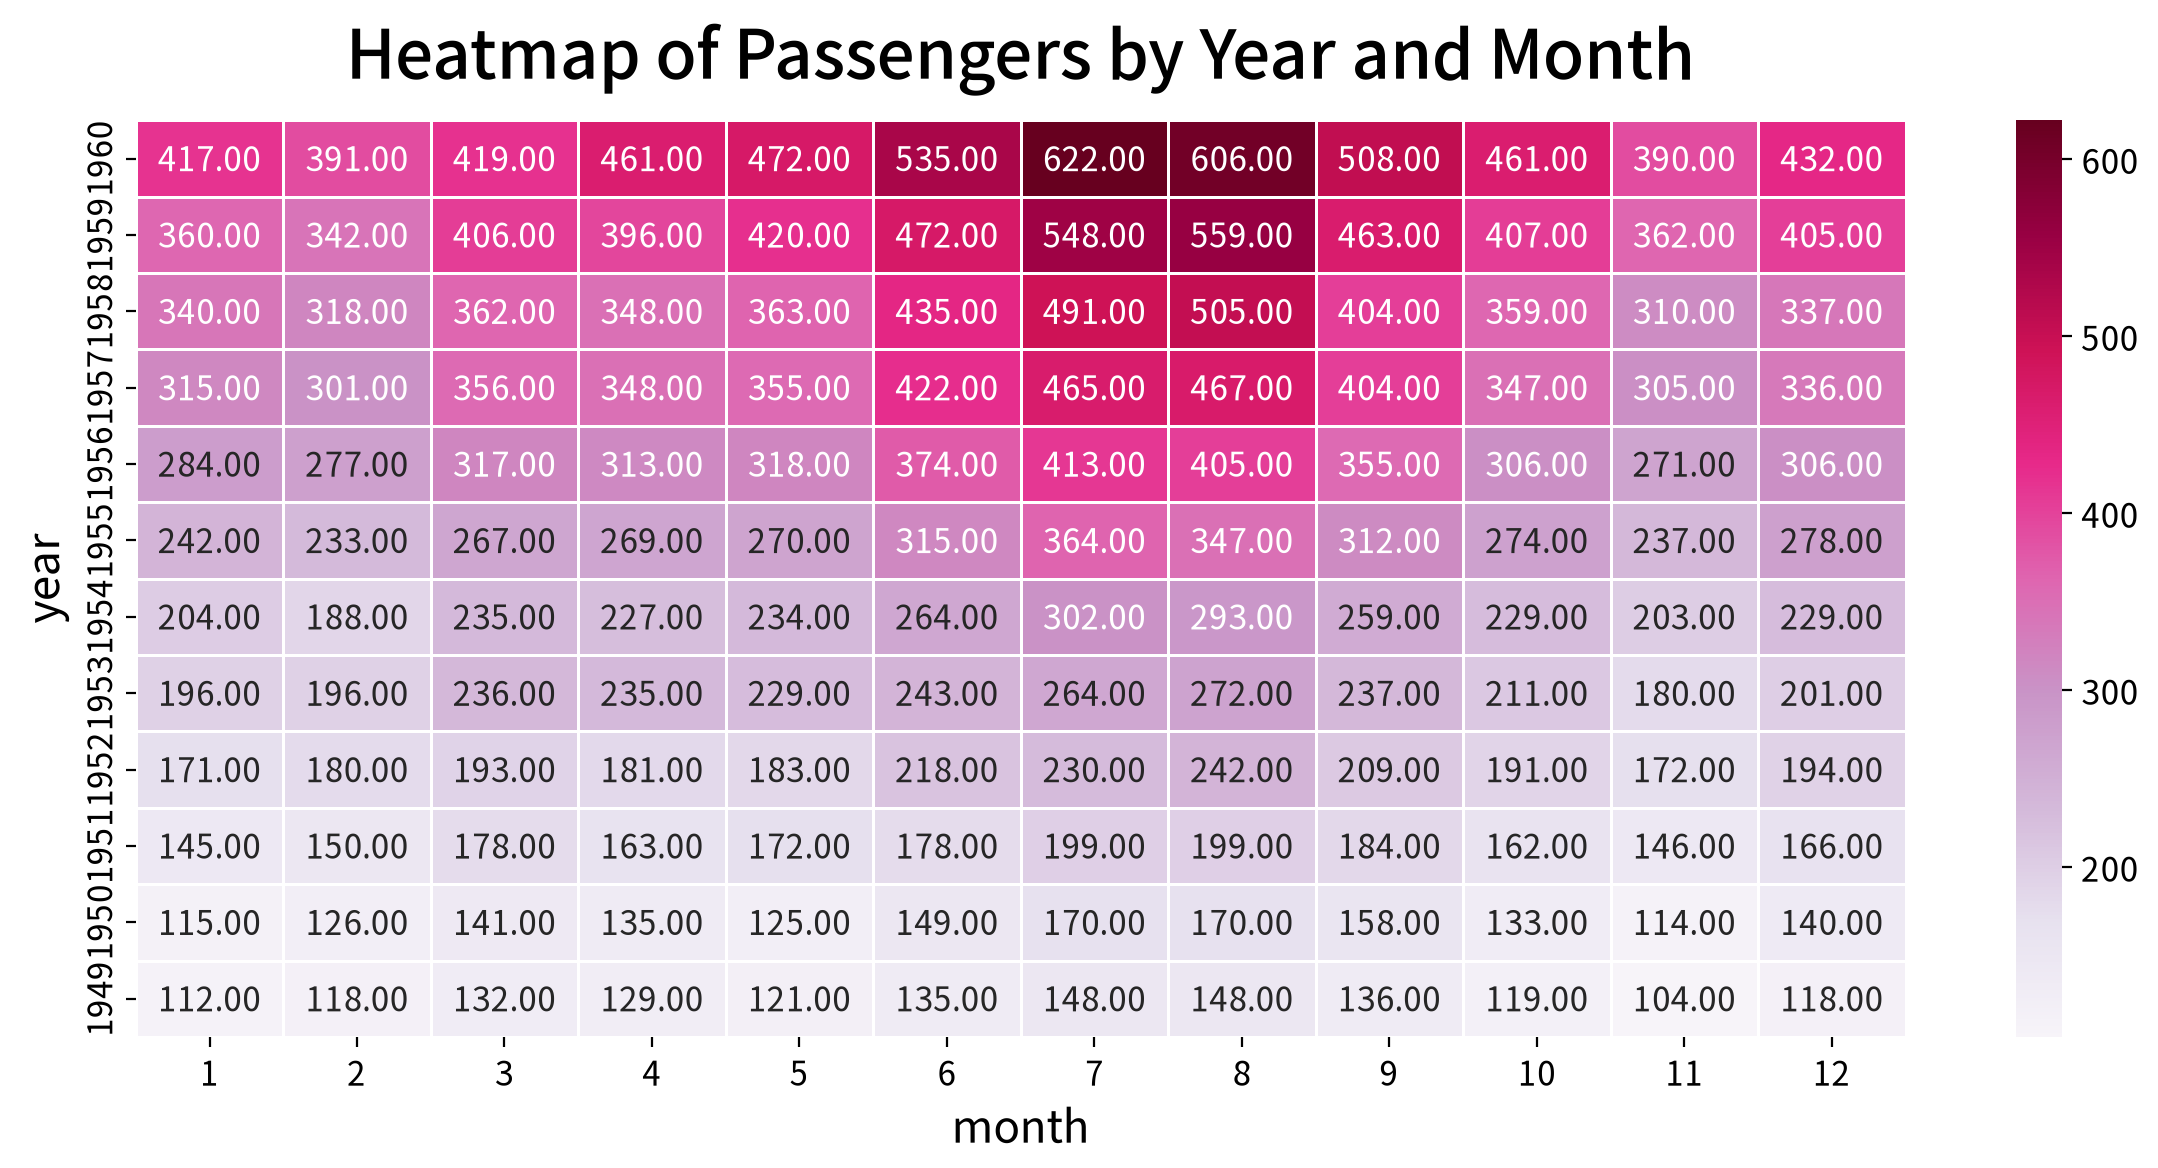

In [7]:
my_plot.heatmap(df3, palette="PuRd", width=1200, height=600,
                title="Heatmap of Passengers by Year and Month",
                xlabel="Month", ylabel="Year")